# Renewable Energy & Price Correlation Analysis — Germany

> Analysing the relationship between renewable generation (solar, wind) and day-ahead electricity prices using ENTSO-E and SMARD data.

**Data sources:**
- ENTSO-E Transparency Platform — hourly generation mix (DE-LU bidding zone)
- SMARD API (Bundesnetzagentur) — German day-ahead prices

**Period:** 2023–2025 (26,300 hourly records)

---

## 1 — Install & Import

In [1]:
!pip install entsoe-py -q
print('entsoe-py installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 8.1 MB/s eta 0:00:00
entsoe-py installed.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import warnings
from entsoe import EntsoePandasClient
from google.colab import userdata
warnings.filterwarnings('ignore')

# ── Renewable and fossil source definitions ──────────────────
RENEWABLE_COLS = [
    'Solar', 'Wind Onshore', 'Wind Offshore',
    'Hydro Run-of-river and poundage',
    'Hydro Water Reservoir', 'Biomass', 'Other renewable'
]
FOSSIL_COLS = [
    'Fossil Gas', 'Fossil Hard coal',
    'Fossil Brown coal/Lignite', 'Fossil Coal-derived gas'
]

print('Libraries loaded.')

Libraries loaded.


## 2 — Fetch Generation Mix (ENTSO-E)

In [3]:
# ── Connect to ENTSO-E API ───────────────────────────────────
token  = userdata.get('ENTSOE_TOKEN')
client = EntsoePandasClient(api_key=token)

COUNTRY = '10Y1001A1001A83F'   # Germany DE-LU bidding zone
START   = pd.Timestamp('20230101', tz='Europe/Berlin')
END     = pd.Timestamp('20260101', tz='Europe/Berlin')

print('Fetching generation data from ENTSO-E...')
gen = client.query_generation(COUNTRY, start=START, end=END, psr_type=None)

# Flatten multi-level columns if present
if isinstance(gen.columns, pd.MultiIndex):
    gen = gen.xs('Actual Aggregated', axis=1, level=1)

print(f'Generation data : {gen.shape}')
print(f'Period          : {gen.index.min().date()} → {gen.index.max().date()}')
print(f'Sources         : {list(gen.columns)}')

Fetching generation data from ENTSO-E...
Generation data : (105214, 17)
Period          : 2023-01-01 → 2025-12-31
Sources         : ['Biomass', 'Fossil Brown coal/Lignite', 'Fossil Coal-derived gas', 'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil', 'Geothermal', 'Hydro Pumped Storage', 'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Nuclear', 'Other', 'Other renewable', 'Solar', 'Waste', 'Wind Offshore', 'Wind Onshore']


## 3 — Fetch Day-Ahead Prices (SMARD)

In [4]:
# ── Fetch all hourly price blocks from SMARD ─────────────────
INDEX_URL  = 'https://www.smard.de/app/chart_data/4169/DE/index_hour.json'
timestamps = requests.get(INDEX_URL).json()['timestamps']
blocks     = sorted(timestamps)

records = []
for i, ts in enumerate(blocks):
    url  = f'https://www.smard.de/app/chart_data/4169/DE/4169_DE_hour_{ts}.json'
    data = requests.get(url).json().get('series', [])
    for entry in data:
        if entry[1] is not None:
            records.append({
                'timestamp': pd.to_datetime(entry[0], unit='ms', utc=True),
                'price':     entry[1]   # EUR/MWh
            })
    if i % 40 == 0:
        print(f'  {i+1}/{len(blocks)} blocks fetched...')

prices = (pd.DataFrame(records)
            .drop_duplicates('timestamp')
            .sort_values('timestamp')
            .set_index('timestamp')
            .tz_convert('Europe/Berlin')
            .squeeze()
            .rename('price_eur_mwh'))

prices = prices[(prices > -500) & (prices.index >= START) & (prices.index < END)]

print(f'Price data : {len(prices):,} hourly records')
print(f'Period     : {prices.index.min().date()} → {prices.index.max().date()}')
print(f'Avg price  : {prices.mean():.1f} €/MWh')

  1/397 blocks fetched...
  41/397 blocks fetched...
  81/397 blocks fetched...
  121/397 blocks fetched...
  161/397 blocks fetched...
  201/397 blocks fetched...
  241/397 blocks fetched...
  281/397 blocks fetched...
  321/397 blocks fetched...
  361/397 blocks fetched...
Price data : 26,303 hourly records
Period     : 2023-01-01 → 2025-12-31
Avg price  : 87.7 €/MWh


## 4 — Merge & Feature Engineering

In [5]:
# ── Resample generation to hourly, strip timezone for merge ──
gen_h = gen.resample('h').mean()

gen_naive    = gen_h.copy()
gen_naive.index = gen_naive.index.tz_localize(None)
gen_naive    = gen_naive[~gen_naive.index.duplicated(keep='first')]

prices_naive = prices.copy()
prices_naive.index = prices_naive.index.tz_localize(None)
prices_naive = prices_naive[~prices_naive.index.duplicated(keep='first')]

# ── Merge and fill missing generation with 0 ────────────────
df = pd.concat([prices_naive, gen_naive], axis=1)
gen_cols = [c for c in gen_naive.columns if c in df.columns]
df[gen_cols] = df[gen_cols].fillna(0)
df = df.dropna(subset=['price_eur_mwh'])

# ── Time features ─────────────────────────────────────────────
df['hour']       = df.index.hour
df['month']      = df.index.month
df['year']       = df.index.year
df['is_weekend'] = df.index.dayofweek >= 5

# ── Aggregate generation features ────────────────────────────
renewable_cols = [c for c in RENEWABLE_COLS if c in df.columns]
fossil_cols    = [c for c in FOSSIL_COLS    if c in df.columns]

df['total_renewable_mw']  = df[renewable_cols].sum(axis=1)
df['total_fossil_mw']     = df[fossil_cols].sum(axis=1)
df['total_generation_mw'] = df[gen_cols].sum(axis=1)
df['renewable_share_pct'] = (
    df['total_renewable_mw'] /
    df['total_generation_mw'].replace(0, np.nan) * 100
).round(1)

print(f'Merged dataset  : {len(df):,} records')
print(f'Period          : {df.index.min().date()} → {df.index.max().date()}')
print(f'Avg renewable   : {df["renewable_share_pct"].mean():.1f}%')
print(f'Avg price       : {df["price_eur_mwh"].mean():.1f} €/MWh')
print(f'Negative hours  : {(df["price_eur_mwh"] < 0).mean()*100:.1f}%')

Merged dataset  : 26,300 records
Period          : 2023-01-01 → 2025-12-31
Avg renewable   : 56.1%
Avg price       : 87.7 €/MWh
Negative hours  : 5.1%


## 5 — Correlation Analysis

In [6]:
# ── Correlation with price ────────────────────────────────────
corr_cols = [
    'price_eur_mwh', 'total_renewable_mw', 'total_fossil_mw',
    'renewable_share_pct', 'Solar', 'Wind Onshore', 'Wind Offshore'
]
corr = df[corr_cols].corr()['price_eur_mwh'].sort_values()
print('Correlation with price (€/MWh):')
print(corr.round(3))

Correlation with price (€/MWh):
renewable_share_pct   -0.766
total_renewable_mw    -0.635
Solar                 -0.433
Wind Onshore          -0.357
Wind Offshore         -0.192
total_fossil_mw        0.714
price_eur_mwh          1.000
Name: price_eur_mwh, dtype: float64


## 6 — Visualisation Panel

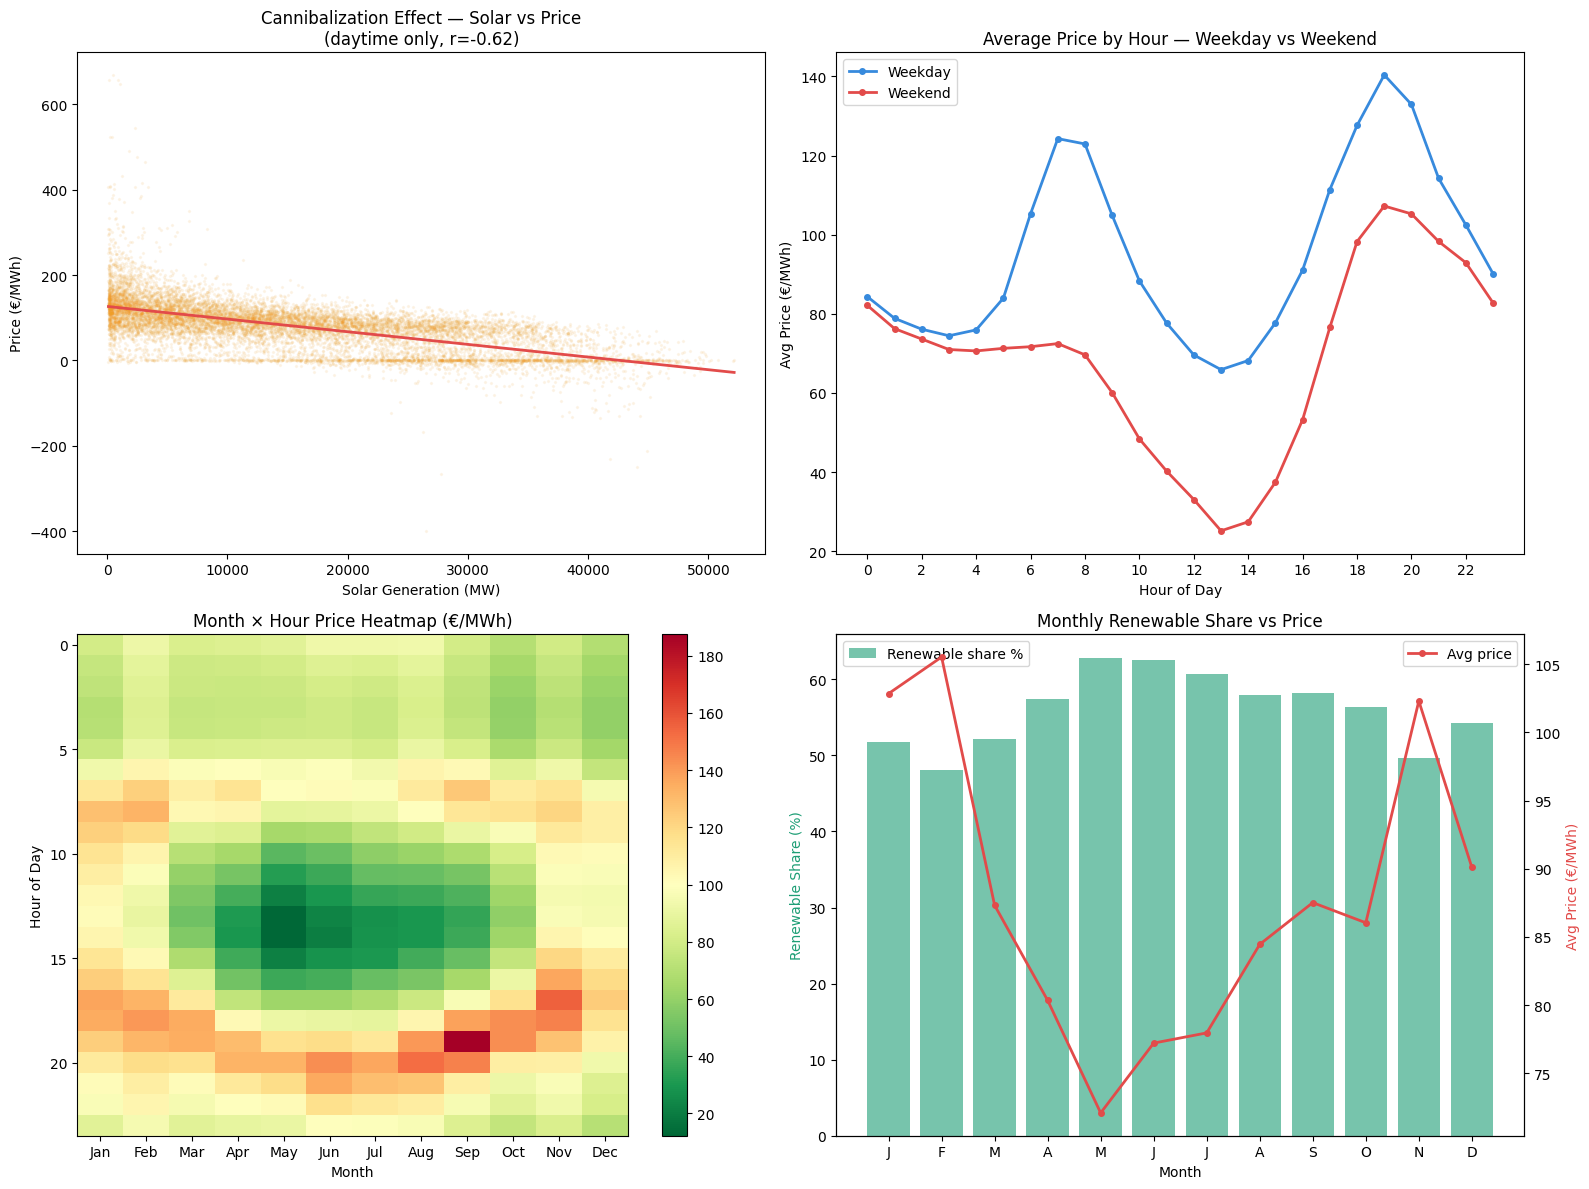

Chart saved.


In [7]:
# ── Daytime subset for cannibalization analysis ───────────────
df_day = df[(df['hour'].between(8, 20)) & (df['Solar'] > 100)]
solar_corr = df_day['Solar'].corr(df_day['price_eur_mwh'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Top-left: Cannibalization effect ─────────────────────────
axes[0,0].scatter(df_day['Solar'], df_day['price_eur_mwh'],
                  alpha=0.08, color='#EF9F27', s=2)
z = np.polyfit(df_day['Solar'], df_day['price_eur_mwh'], 1)
x_line = np.linspace(df_day['Solar'].min(), df_day['Solar'].max(), 100)
axes[0,0].plot(x_line, np.poly1d(z)(x_line), color='#E24B4A', linewidth=2)
axes[0,0].set_title(f'Cannibalization Effect — Solar vs Price\n(daytime only, r={solar_corr:.2f})')
axes[0,0].set_xlabel('Solar Generation (MW)')
axes[0,0].set_ylabel('Price (€/MWh)')

# ── Top-right: Weekday vs weekend hourly profile ──────────────
hourly_wd = df[~df['is_weekend']].groupby('hour')['price_eur_mwh'].mean()
hourly_we = df[ df['is_weekend']].groupby('hour')['price_eur_mwh'].mean()
axes[0,1].plot(hourly_wd.index, hourly_wd.values,
               color='#378ADD', linewidth=2, marker='o', ms=4, label='Weekday')
axes[0,1].plot(hourly_we.index, hourly_we.values,
               color='#E24B4A', linewidth=2, marker='o', ms=4, label='Weekend')
axes[0,1].set_title('Average Price by Hour — Weekday vs Weekend')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Avg Price (€/MWh)')
axes[0,1].legend()
axes[0,1].set_xticks(range(0, 24, 2))

# ── Bottom-left: Month × Hour heatmap ────────────────────────
pivot = df.pivot_table(index='hour', columns='month',
                       values='price_eur_mwh', aggfunc='mean')
im = axes[1,0].imshow(pivot.values, aspect='auto', cmap='RdYlGn_r')
axes[1,0].set_title('Month × Hour Price Heatmap (€/MWh)')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Hour of Day')
axes[1,0].set_xticks(range(12))
axes[1,0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.colorbar(im, ax=axes[1,0])

# ── Bottom-right: Monthly renewable share vs price ────────────
monthly_re = df.groupby('month')['renewable_share_pct'].mean()
monthly_px = df.groupby('month')['price_eur_mwh'].mean()
ax2 = axes[1,1].twinx()
axes[1,1].bar(monthly_re.index, monthly_re.values,
              color='#1D9E75', alpha=0.6, label='Renewable share %')
ax2.plot(monthly_px.index, monthly_px.values,
         color='#E24B4A', linewidth=2, marker='o', ms=4, label='Avg price')
axes[1,1].set_title('Monthly Renewable Share vs Price')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Renewable Share (%)', color='#1D9E75')
ax2.set_ylabel('Avg Price (€/MWh)', color='#E24B4A')
axes[1,1].set_xticks(range(1, 13))
axes[1,1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1,1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('renewable_correlation_panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

## 7 — Key Findings

In [8]:
print('=' * 55)
print('  RENEWABLE & PRICE CORRELATION — KEY FINDINGS')
print('=' * 55)
print(f'  Dataset              : {len(df):,} hourly records (2023–2025)')
print(f'  Avg renewable share  : {df["renewable_share_pct"].mean():.1f}%')
print(f'  Renewable vs price   : r = {df["renewable_share_pct"].corr(df["price_eur_mwh"]):.3f}')
print(f'  Solar vs price       : r = {solar_corr:.3f} (daytime only)')
print(f'  Wind Onshore vs price: r = {df["Wind Onshore"].corr(df["price_eur_mwh"]):.3f}')
print(f'  Fossil vs price      : r = {df["total_fossil_mw"].corr(df["price_eur_mwh"]):.3f}')
print(f'  Negative price hours : {(df["price_eur_mwh"] < 0).mean()*100:.1f}%')
print(f'  Highest price month  : {df.groupby("month")["price_eur_mwh"].mean().idxmax()} (month)')
print(f'  Lowest price month   : {df.groupby("month")["price_eur_mwh"].mean().idxmin()} (month)')
print('=' * 55)

  RENEWABLE & PRICE CORRELATION — KEY FINDINGS
  Dataset              : 26,300 hourly records (2023–2025)
  Avg renewable share  : 56.1%
  Renewable vs price   : r = -0.766
  Solar vs price       : r = -0.623 (daytime only)
  Wind Onshore vs price: r = -0.357
  Fossil vs price      : r = 0.714
  Negative price hours : 5.1%
  Highest price month  : 2 (month)
  Lowest price month   : 5 (month)
